# Notebook 10 — Explainability (Concept Bottleneck)

v1 modelinin (advanced_v1, det 0.998 / mal 0.986 / Dice 0.857) **açıklanabilirlik** analizleri. Yeniden eğitim YOK.

Model **saf CBM**: `malignancy = Linear(8 concept → 2)`. Malignancy kararı yalnızca 8 klinik concept üzerinden geçer; bu, her tahmini concept'ler cinsinden kesin açıklamayı sağlar.

Üretilenler: (1) concept katkı analizi, (2) concept intervention, (3) saliency, (4) multi-task görsel.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install monai --quiet

import os, gc, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
from monai.networks.nets import ViT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.3 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


device: cuda


## 2. Config

In [2]:
DAPT_CKPT = '/content/drive/MyDrive/bitirme/Checkpoints_DAPT/pulmomae_dapt_epoch3_20260525-210449_model_only.pth'
CHECKPOINTS_DIR = '/content/drive/MyDrive/bitirme/Checkpoints_Advanced'
TEST_H5 = '/content/drive/MyDrive/bitirme/Finetune_Patches/patches_test.h5'

ROI_SIZE = (64, 64, 64)
N_CONCEPTS = 8
USE_MAE = True
MAE_PATCH_SIZE = (16, 16, 16)
MAE_HIDDEN_SIZE = 1024
MAE_MLP_DIM = 4096
MAE_NUM_LAYERS = 24
MAE_NUM_HEADS = 16
HU_CLIP = (-1000, 1000)

CONCEPT_NAMES = ['subtlety', 'internalStructure', 'calcification', 'sphericity',
                 'margin', 'lobulation', 'spiculation', 'texture']
print('Config OK')

Config OK


## 3. Model tanımı (Notebook 9 ile aynı)

In [3]:
class ResBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False)
        self.norm1 = nn.InstanceNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm3d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.skip = nn.Conv3d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        identity = self.skip(x)
        out = self.act(self.norm1(self.conv1(x)))
        out = self.norm2(self.conv2(out))
        return self.act(out + identity)

class UNet3D(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.stem  = ResBlock3D(in_channels, base)
        self.down1 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*4, base*8))
        self.bottom = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*8, base*16))
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.up4 = nn.ConvTranspose3d(base*16, base*8, 2, 2); self.dec4 = ResBlock3D(base*16, base*8)
        self.up3 = nn.ConvTranspose3d(base*8, base*4, 2, 2);  self.dec3 = ResBlock3D(base*8, base*4)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, 2);  self.dec2 = ResBlock3D(base*4, base*2)
        self.up1 = nn.ConvTranspose3d(base*2, base, 2, 2);    self.dec1 = ResBlock3D(base*2, base)
        self.final = nn.Conv3d(base, 1, 1)
        self.out_dim = base * 16
    def forward(self, x):
        s0 = self.stem(x); s1 = self.down1(s0); s2 = self.down2(s1); s3 = self.down3(s2)
        b = self.bottom(s3)
        global_feat = self.global_pool(b).flatten(1)
        u4 = self.up4(b);  d4 = self.dec4(torch.cat([u4, s3], dim=1))
        u3 = self.up3(d4); d3 = self.dec3(torch.cat([u3, s2], dim=1))
        u2 = self.up2(d3); d2 = self.dec2(torch.cat([u2, s1], dim=1))
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([u1, s0], dim=1))
        seg_logits = self.final(d1)
        return global_feat, seg_logits

class HybridMultiTaskCBM(nn.Module):
    def __init__(self, mae_encoder=None, n_concepts=8, use_mae=True, head_dropout=0.1):
        super().__init__()
        self.n_concepts = n_concepts
        self.use_mae = use_mae and (mae_encoder is not None)
        self.mae_encoder = mae_encoder
        if self.mae_encoder is not None:
            for p in self.mae_encoder.parameters(): p.requires_grad = False
            self.mae_encoder.eval()
        self.cnn = UNet3D(in_channels=1, base=32)
        combined_dim = self.cnn.out_dim + (MAE_HIDDEN_SIZE if self.use_mae else 0)
        self.detection_head = nn.Sequential(
            nn.LayerNorm(combined_dim), nn.Linear(combined_dim, 256), nn.GELU(),
            nn.Dropout(head_dropout), nn.Linear(256, 2))
        self.concept_head = nn.Sequential(
            nn.LayerNorm(combined_dim), nn.Linear(combined_dim, 256), nn.GELU(),
            nn.Dropout(0.3), nn.Linear(256, n_concepts))
        self.malignancy_head = nn.Linear(n_concepts, 2)
    def forward(self, x):
        cnn_global, seg_logits = self.cnn(x)
        if self.use_mae:
            with torch.no_grad():
                mae_tokens, _ = self.mae_encoder(x)
                mae_global = mae_tokens.mean(dim=1)
            combined = torch.cat([mae_global, cnn_global], dim=1)
        else:
            combined = cnn_global
        det = self.detection_head(combined)
        concepts = self.concept_head(combined)
        mal = self.malignancy_head(concepts)
        return {'detection': det, 'concepts': concepts, 'malignancy': mal, 'segmentation': seg_logits}

print('Model class OK')

Model class OK


## 4. Model oluştur + v1 best checkpoint yükle

In [5]:
model = HybridMultiTaskCBM(mae_encoder=None, n_concepts=N_CONCEPTS, use_mae=False).to(device)

def sort_key(n):
    m = re.match(r'advanced_v1_epoch(\d+)_best_.*_full\.pth$', n)
    return int(m.group(1)) if m else -1
best_files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                     if 'advanced_v1' in f and '_best_' in f and f.endswith('_full.pth')],
                    key=sort_key)
assert best_files, 'advanced_v1 best checkpoint bulunamadı!'
best_path = os.path.join(CHECKPOINTS_DIR, best_files[-1])
print('Yüklenen:', os.path.basename(best_path))

ckpt = torch.load(best_path, map_location=device, weights_only=False)
missing, unexpected = model.load_state_dict(ckpt['model_state_dict'], strict=False)
print(f'  Eksik: {len(missing)}, beklenmedik: {len(unexpected)}')
if missing:     print('  Eksik örnek:', missing[:5])
if unexpected:  print('  Beklenmedik örnek:', unexpected[:5])
print(f'  Epoch {ckpt.get("epoch")}, best_mal_auc={ckpt.get("best_val_mal_auc")}')
model.eval()
print('Model hazır ✅')

Yüklenen: advanced_v1_epoch51_best_20260528-094231_full.pth
  Eksik: 0, beklenmedik: 0
  Epoch 51, best_mal_auc=0.986111111111111
Model hazır ✅


## 5. Global concept önemi (malignancy_head ağırlıkları)

Malign logiti = Σ (w_net[i] × concept_i). w_net = w[malign] - w[benign].

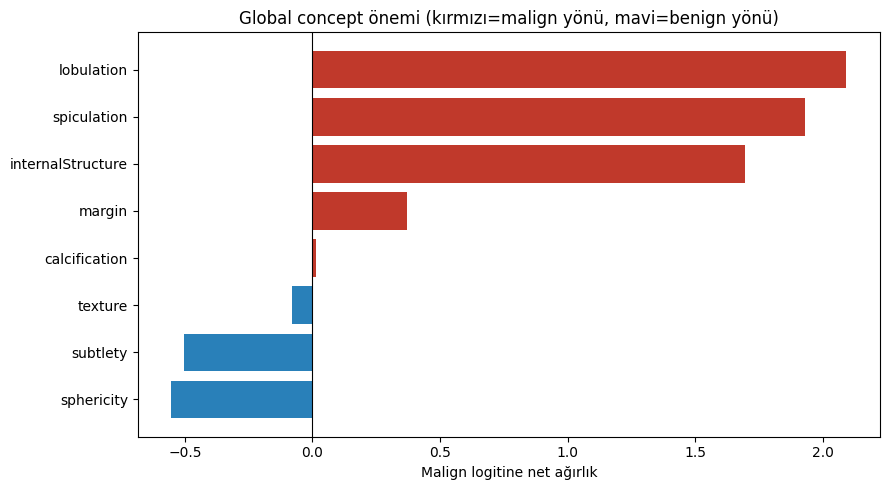

  lobulation        : +2.093
  spiculation       : +1.932
  internalStructure : +1.697
  margin            : +0.372
  calcification     : +0.015
  texture           : -0.080
  subtlety          : -0.505
  sphericity        : -0.553


In [6]:
W = model.malignancy_head.weight.detach().cpu().numpy()
w_net = W[1] - W[0]
order = np.argsort(w_net)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if w_net[i] > 0 else '#2980b9' for i in order]
ax.barh([CONCEPT_NAMES[i] for i in order], [w_net[i] for i in order], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Malign logitine net ağırlık')
ax.set_title('Global concept önemi (kırmızı=malign yönü, mavi=benign yönü)')
plt.tight_layout(); plt.savefig('/content/concept_global_importance.png', dpi=120); plt.show()
for i in order[::-1]:
    print(f'  {CONCEPT_NAMES[i]:18s}: {w_net[i]:+.3f}')

## 6. Test verisini yükle

In [7]:
with h5py.File(TEST_H5, 'r') as h5:
    patches_all  = h5['patches'][:]
    masks_all    = h5['masks'][:]
    det_all      = h5['detection'][:]
    mal_all      = h5['malignancy'][:]
    concepts_all = h5['concepts'][:]
print('Test patch:', patches_all.shape)
labeled = np.where(mal_all != -1)[0]
print(f'Etiketli: {len(labeled)} (malign={int((mal_all[labeled]==1).sum())}, benign={int((mal_all[labeled]==0).sum())})')

def prep_patch(idx):
    p = np.clip(patches_all[idx].astype(np.float32), HU_CLIP[0], HU_CLIP[1])
    p = (p - HU_CLIP[0]) / (HU_CLIP[1] - HU_CLIP[0])
    return torch.from_numpy(p[None, None]).to(device)

Test patch: (1130, 64, 64, 64)
Etiketli: 81 (malign=34, benign=47)


## 7. Tek vaka concept katkı analizi

=== MALIGN örneği ===


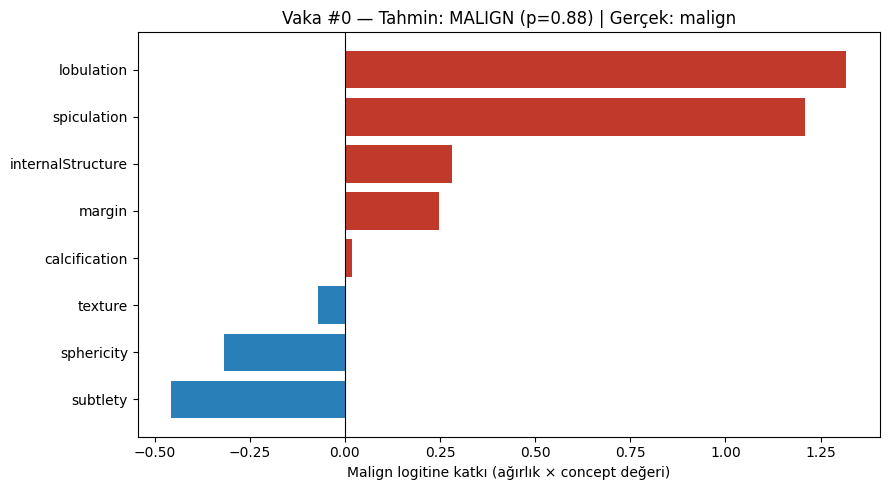

  lobulation        : pred=+0.63  katkı=+1.318
  spiculation       : pred=+0.63  katkı=+1.210
  internalStructure : pred=+0.17  katkı=+0.280
  margin            : pred=+0.67  katkı=+0.248
  calcification     : pred=+1.18  katkı=+0.018
  texture           : pred=+0.88  katkı=-0.070
  sphericity        : pred=+0.57  katkı=-0.316
  subtlety          : pred=+0.90  katkı=-0.456

=== BENIGN örneği ===


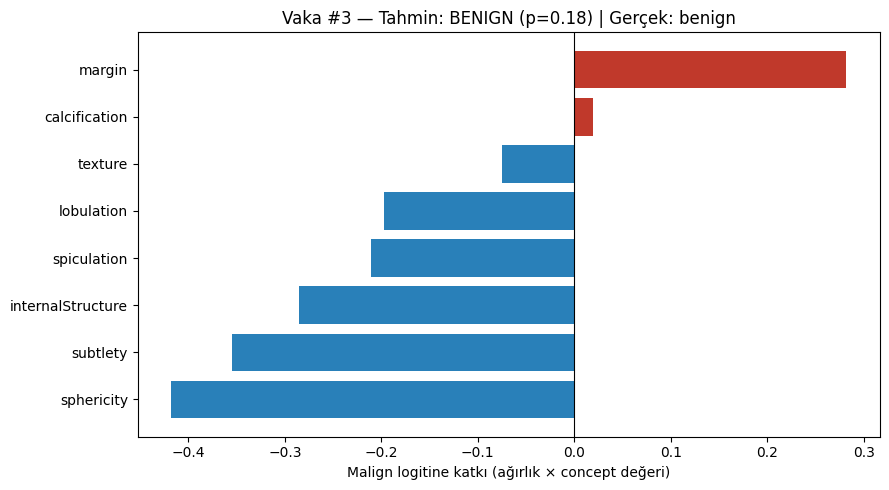

  margin            : pred=+0.76  katkı=+0.282
  calcification     : pred=+1.23  katkı=+0.019
  texture           : pred=+0.94  katkı=-0.075
  lobulation        : pred=-0.09  katkı=-0.197
  spiculation       : pred=-0.11  katkı=-0.210
  internalStructure : pred=-0.17  katkı=-0.285
  subtlety          : pred=+0.70  katkı=-0.355
  sphericity        : pred=+0.76  katkı=-0.418


(0.17891530692577362,
 array([-0.35523632, -0.28532776,  0.01908486, -0.4176259 ,  0.28204495,
        -0.19749573, -0.2104675 , -0.07529397], dtype=float32),
 array([ 0.70356065, -0.16816881,  1.2322078 ,  0.75517154,  0.75822955,
        -0.09435473, -0.10895406,  0.9400351 ], dtype=float32))

In [8]:
def explain_case(idx, show=True):
    with torch.no_grad():
        out = model(prep_patch(idx))
    concept_pred = out['concepts'][0].cpu().numpy()
    mal_prob = torch.softmax(out['malignancy'][0], 0)[1].item()
    contrib = w_net * concept_pred
    pred = 'MALIGN' if mal_prob > 0.5 else 'BENIGN'
    gt = 'malign' if mal_all[idx] == 1 else 'benign'
    if show:
        o = np.argsort(contrib)
        fig, ax = plt.subplots(figsize=(9, 5))
        colors = ['#c0392b' if contrib[i] > 0 else '#2980b9' for i in o]
        ax.barh([CONCEPT_NAMES[i] for i in o], [contrib[i] for i in o], color=colors)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_xlabel('Malign logitine katkı (ağırlık × concept değeri)')
        ax.set_title(f'Vaka #{idx} — Tahmin: {pred} (p={mal_prob:.2f}) | Gerçek: {gt}')
        plt.tight_layout(); plt.show()
        for i in np.argsort(contrib)[::-1]:
            print(f'  {CONCEPT_NAMES[i]:18s}: pred={concept_pred[i]:+.2f}  katkı={contrib[i]:+.3f}')
    return mal_prob, contrib, concept_pred

malign_idx = labeled[mal_all[labeled] == 1]
benign_idx = labeled[mal_all[labeled] == 0]
print('=== MALIGN örneği ==='); explain_case(int(malign_idx[0]))
print('\n=== BENIGN örneği ==='); explain_case(int(benign_idx[0]))

## 8. Concept intervention

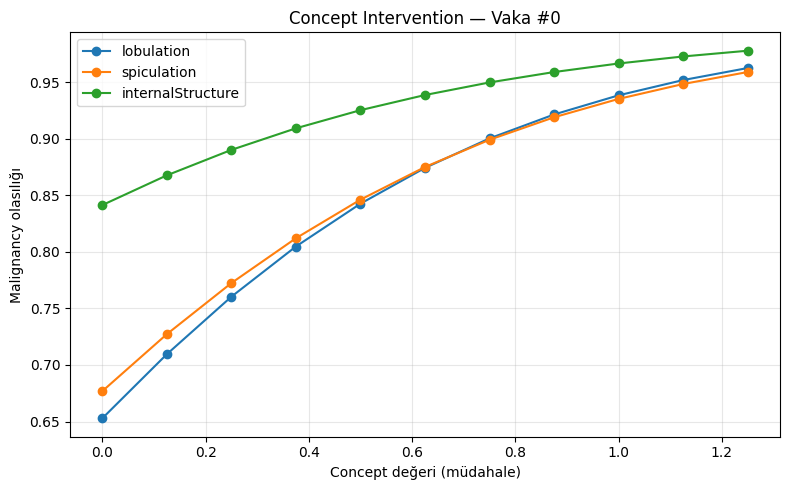

Eğri dik → model o concept'e duyarlı


In [9]:
def intervene(idx, ci, sweep):
    with torch.no_grad():
        out = model(prep_patch(idx))
    base = out['concepts'][0].clone()
    probs = []
    for v in sweep:
        c = base.clone(); c[ci] = float(v)
        logit = model.malignancy_head(c.unsqueeze(0))
        probs.append(torch.softmax(logit, 1)[0, 1].item())
    return np.array(probs)

case = int(malign_idx[0])
top3 = np.argsort(np.abs(w_net))[::-1][:3]
sweep = np.linspace(0, 1.25, 11)
fig, ax = plt.subplots(figsize=(8, 5))
for ci in top3:
    ax.plot(sweep, intervene(case, ci, sweep), marker='o', label=CONCEPT_NAMES[ci])
ax.set_xlabel('Concept değeri (müdahale)'); ax.set_ylabel('Malignancy olasılığı')
ax.set_title(f'Concept Intervention — Vaka #{case}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/concept_intervention.png', dpi=120); plt.show()
print('Eğri dik → model o concept\'e duyarlı')

## 9. Saliency — model nereye bakıyor

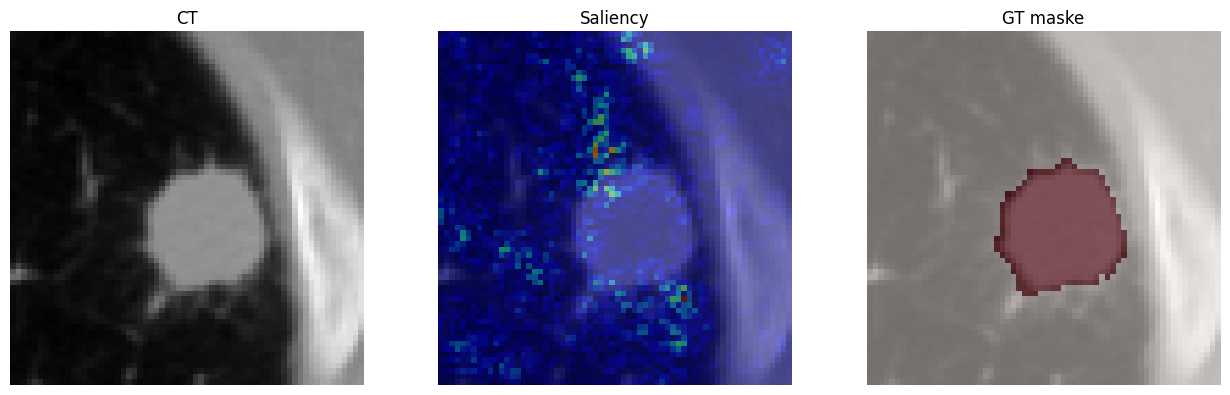

In [10]:
def saliency_map(idx):
    x = prep_patch(idx).clone().requires_grad_(True)
    out = model(x)
    score = out['malignancy'][0, 1]
    model.zero_grad()
    score.backward()
    return x.grad[0, 0].abs().cpu().numpy()

case = int(malign_idx[0])
sal = saliency_map(case)
pn = np.clip(patches_all[case].astype(np.float32), HU_CLIP[0], HU_CLIP[1])
pn = (pn - HU_CLIP[0]) / (HU_CLIP[1] - HU_CLIP[0])
z = ROI_SIZE[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(pn[z], cmap='gray'); axes[0].set_title('CT'); axes[0].axis('off')
axes[1].imshow(pn[z], cmap='gray'); axes[1].imshow(sal[z], cmap='jet', alpha=0.5)
axes[1].set_title('Saliency'); axes[1].axis('off')
axes[2].imshow(pn[z], cmap='gray')
if masks_all[case].sum() > 0: axes[2].imshow(masks_all[case][z], cmap='Reds', alpha=0.45)
axes[2].set_title('GT maske'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('/content/saliency.png', dpi=120); plt.show()

## 10. Multi-task görsel açıklama

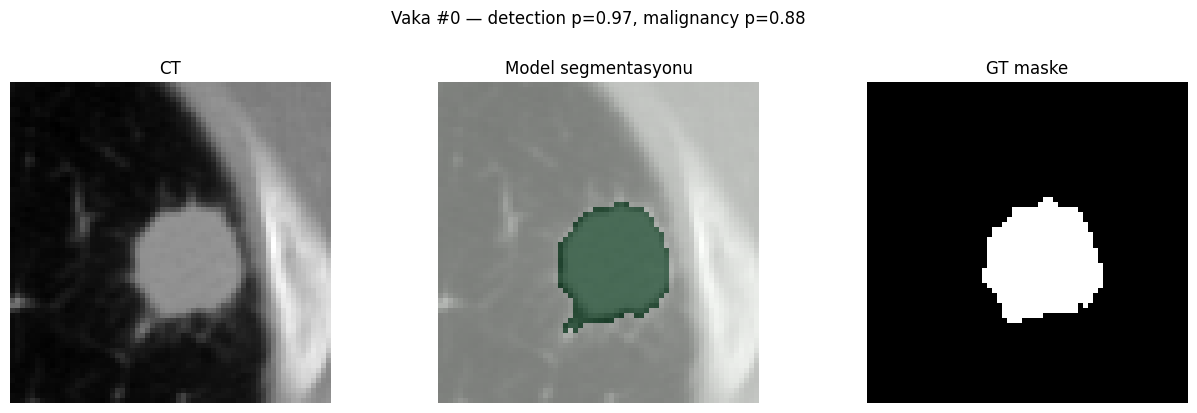

In [11]:
case = int(malign_idx[0])
with torch.no_grad():
    out = model(prep_patch(case))
seg_pred = torch.sigmoid(out['segmentation'][0, 0]).cpu().numpy()
det_p = torch.softmax(out['detection'][0], 0)[1].item()
mal_p = torch.softmax(out['malignancy'][0], 0)[1].item()
pn = np.clip(patches_all[case].astype(np.float32), HU_CLIP[0], HU_CLIP[1])
pn = (pn - HU_CLIP[0]) / (HU_CLIP[1] - HU_CLIP[0])
z = ROI_SIZE[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(pn[z], cmap='gray'); axes[0].set_title('CT'); axes[0].axis('off')
axes[1].imshow(pn[z], cmap='gray'); axes[1].imshow(seg_pred[z] > 0.5, cmap='Greens', alpha=0.5)
axes[1].set_title('Model segmentasyonu'); axes[1].axis('off')
axes[2].imshow(masks_all[case][z], cmap='gray'); axes[2].set_title('GT maske'); axes[2].axis('off')
plt.suptitle(f'Vaka #{case} — detection p={det_p:.2f}, malignancy p={mal_p:.2f}', y=1.02)
plt.tight_layout(); plt.savefig('/content/multitask_explain.png', dpi=120); plt.show()

## 11. Tüm test seti — ortalama concept katkıları

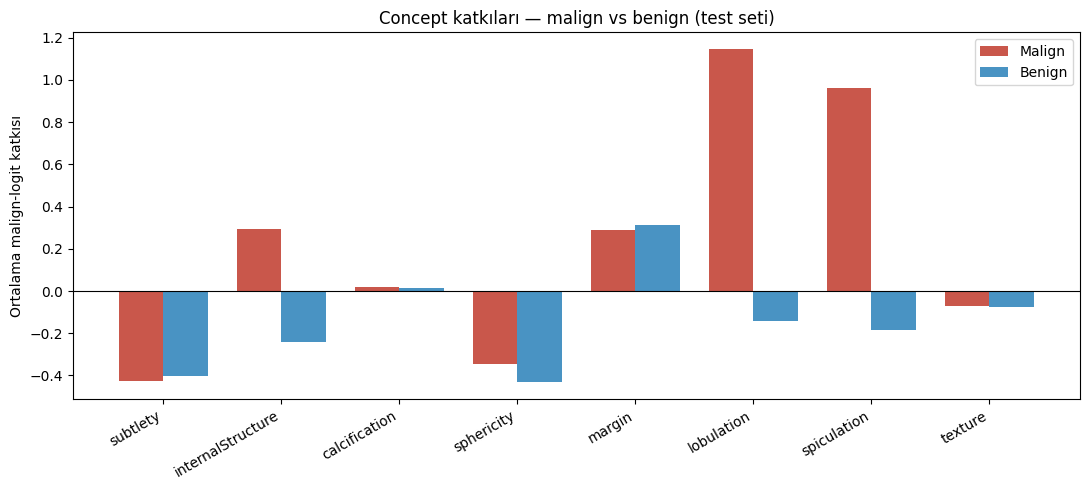

Malign vakalarda en baskın concept'ler:
  lobulation        : +1.146
  spiculation       : +0.963
  internalStructure : +0.294
  margin            : +0.289

Görseller /content/ altına kaydedildi.


In [12]:
mal_c, ben_c = [], []
for idx in labeled:
    _, contrib, _ = explain_case(int(idx), show=False)
    (mal_c if mal_all[idx] == 1 else ben_c).append(contrib)
mal_c = np.array(mal_c); ben_c = np.array(ben_c)
x = np.arange(N_CONCEPTS); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, mal_c.mean(0), w, label='Malign', color='#c0392b', alpha=0.85)
ax.bar(x + w/2, ben_c.mean(0), w, label='Benign', color='#2980b9', alpha=0.85)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CONCEPT_NAMES, rotation=30, ha='right')
ax.set_ylabel('Ortalama malign-logit katkısı')
ax.set_title('Concept katkıları — malign vs benign (test seti)')
ax.legend(); plt.tight_layout(); plt.savefig('/content/concept_summary.png', dpi=120); plt.show()
print('Malign vakalarda en baskın concept\'ler:')
for i in np.argsort(mal_c.mean(0))[::-1][:4]:
    print(f'  {CONCEPT_NAMES[i]:18s}: {mal_c.mean(0)[i]:+.3f}')
print('\nGörseller /content/ altına kaydedildi.')